# Task 2: Technical Analysis of Stock Prices
This notebook uses TA-Lib to compute technical indicators like SMA, RSI, and MACD for AAPL, AMZN, GOOG, META, MSFT, NVDA, and TSLA.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import talib

In [2]:
def load_all_stock_data(tickers, path='../data/yfinance_data/'):
    stock_data = {}
    for ticker in tickers:
        file_path = os.path.join(path, f"{ticker}.csv")
        df = pd.read_csv(file_path, parse_dates=['Date'])
        df.sort_values('Date', inplace=True)
        df.set_index('Date', inplace=True)
        stock_data[ticker] = df
    return stock_data

# Ticker symbols
tickers = ['AAPL_historical_data', 'AMZN_historical_data', 'GOOG_historical_data', 'META_historical_data', 'MSFT_historical_data', 'NVDA_historical_data', 'TSLA_historical_data']

# Load all
all_stocks = load_all_stock_data(tickers)

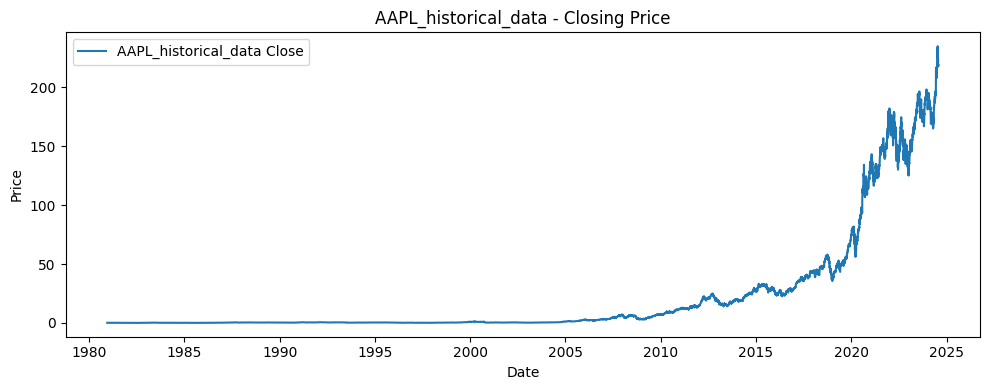

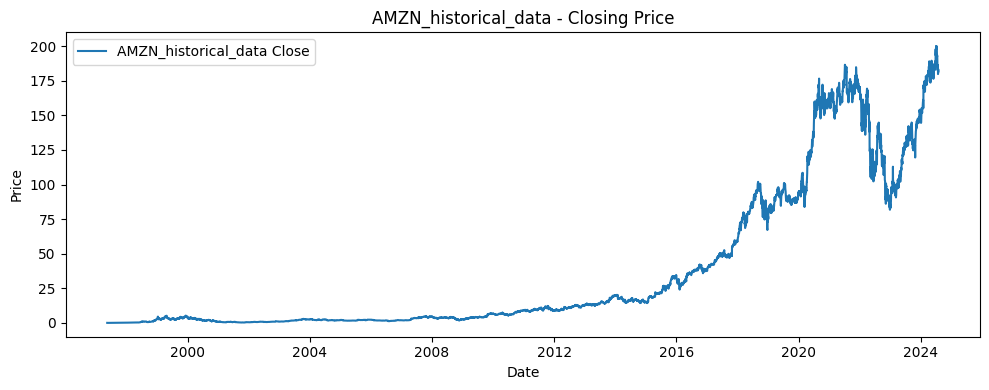

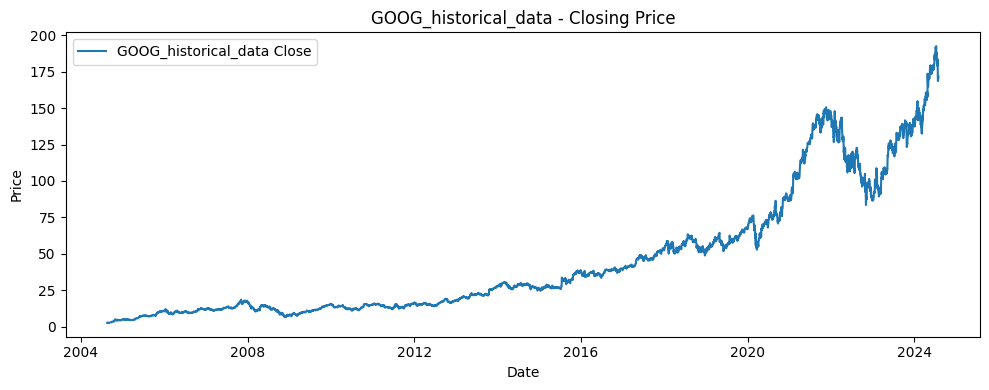

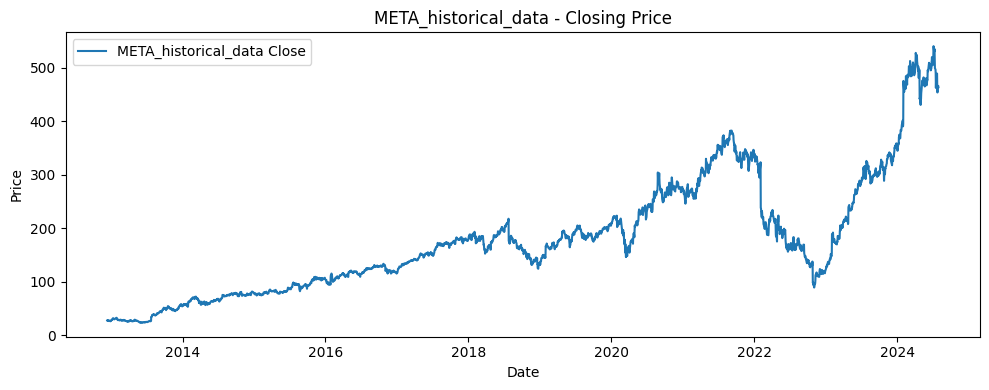

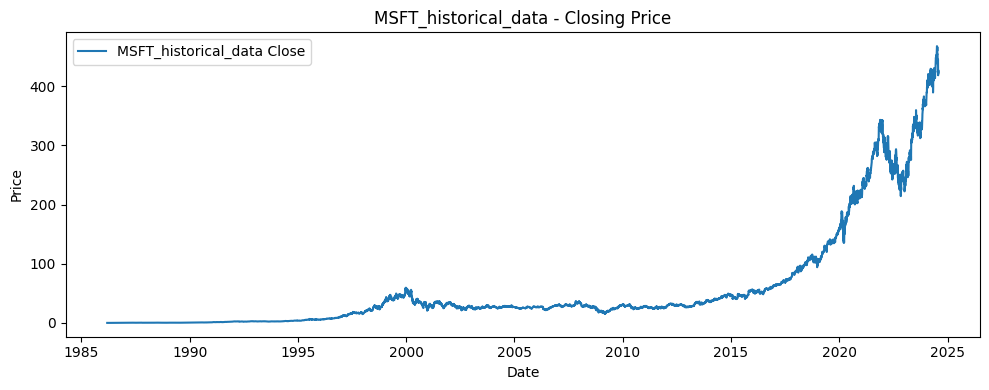

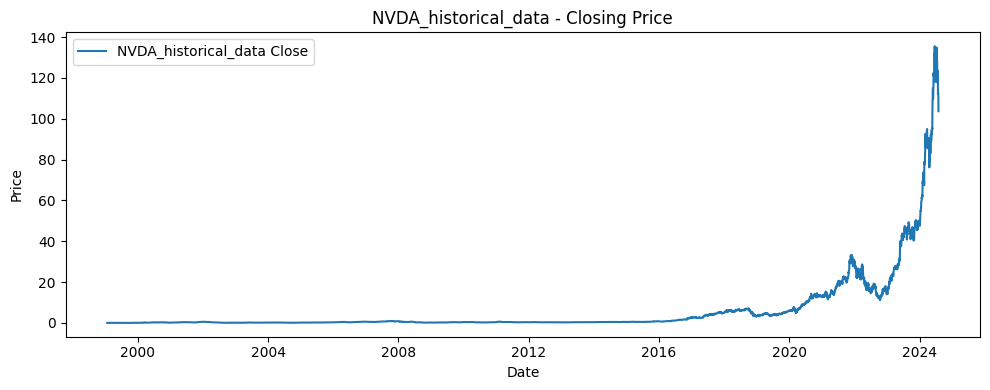

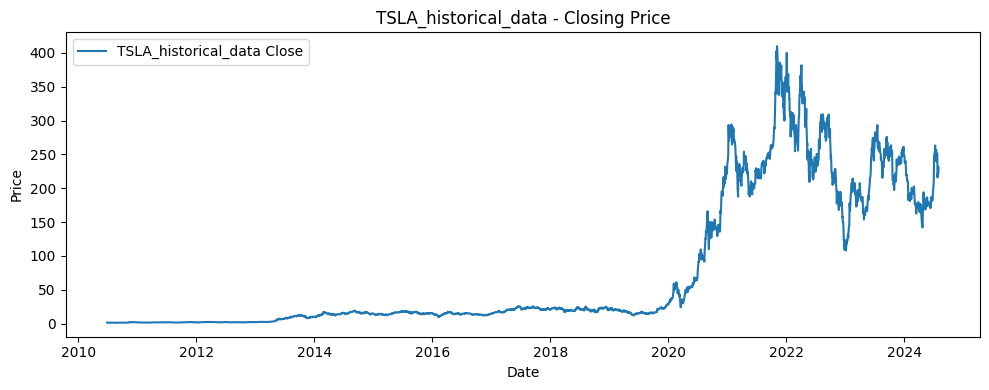

In [3]:
for ticker, df in all_stocks.items():
    plt.figure(figsize=(10, 4))
    plt.plot(df['Close'], label=f'{ticker} Close')
    plt.title(f'{ticker} - Closing Price')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.tight_layout()
    plt.show()


In [5]:
for ticker, df in all_stocks.items():
    close = df['Close'].values  # TA-Lib requires NumPy arrays

    # Add technical indicators
    df['SMA_20'] = talib.SMA(close, timeperiod=20)
    df['RSI_14'] = talib.RSI(close, timeperiod=14)
    df['MACD'], df['MACD_signal'], df['MACD_hist'] = talib.MACD(close)


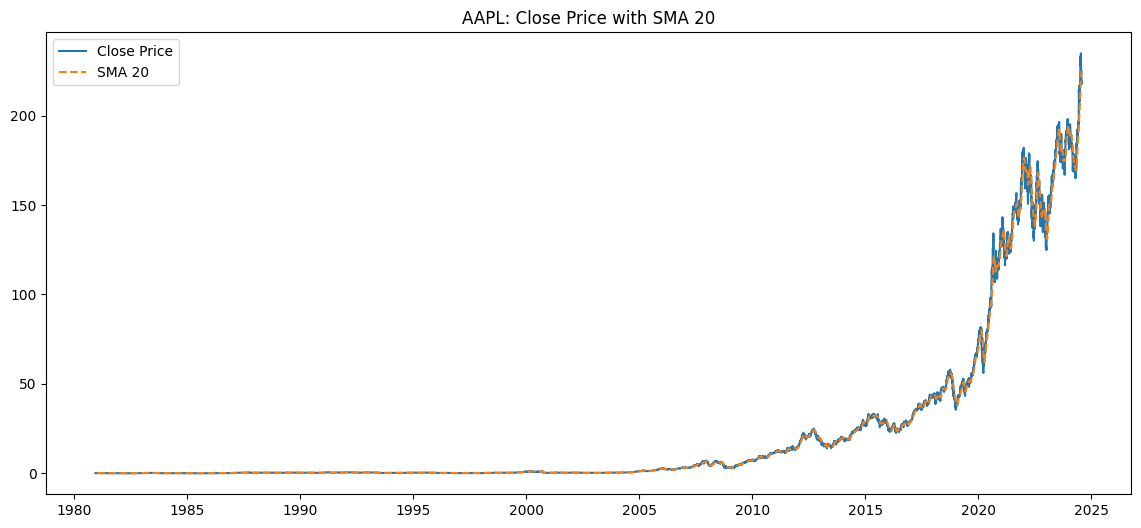

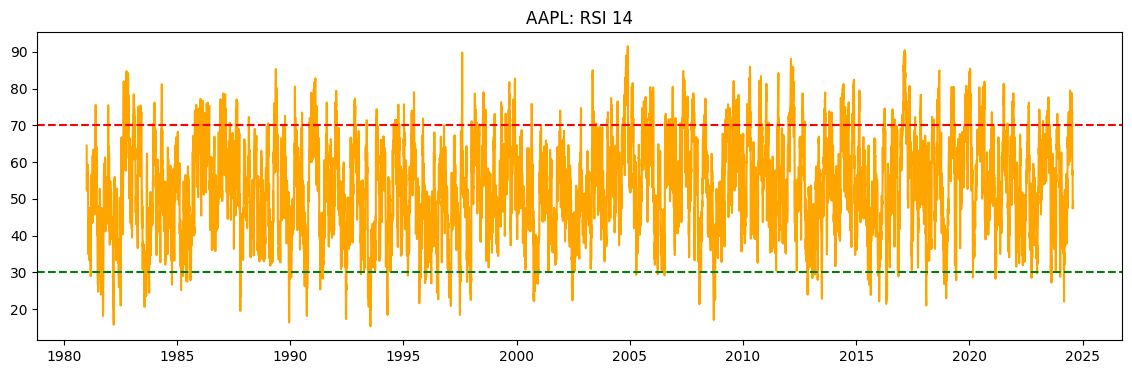

c:\Users\Bereket\Documents\Tenx\Week 1\aim-week1-challenge\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


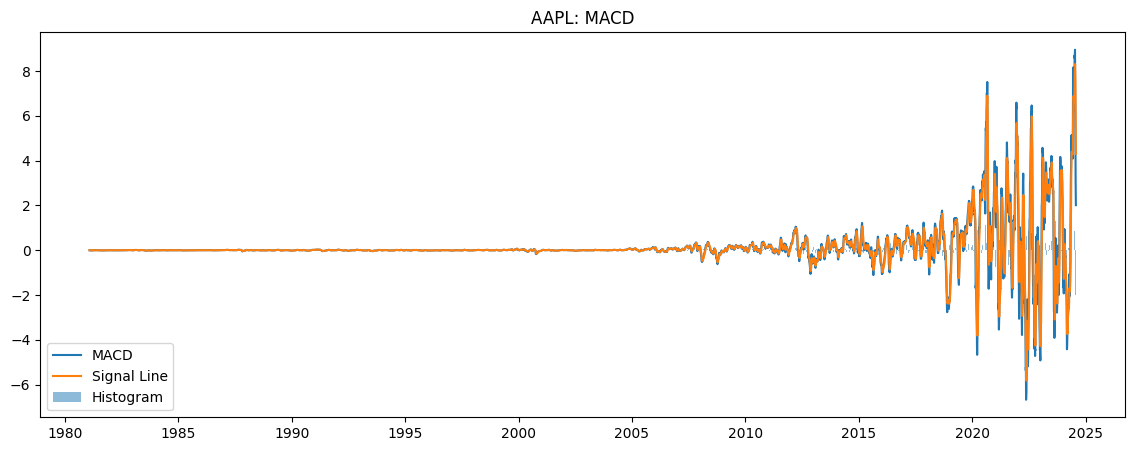

In [6]:
aapl = all_stocks['AAPL_historical_data']

# Plot Close + SMA
plt.figure(figsize=(14, 6))
plt.plot(aapl['Close'], label='Close Price')
plt.plot(aapl['SMA_20'], label='SMA 20', linestyle='--')
plt.title('AAPL: Close Price with SMA 20')
plt.legend()
plt.show()

# Plot RSI
plt.figure(figsize=(14, 4))
plt.plot(aapl['RSI_14'], color='orange')
plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='green', linestyle='--')
plt.title('AAPL: RSI 14')
plt.show()

# Plot MACD
plt.figure(figsize=(14, 5))
plt.plot(aapl['MACD'], label='MACD')
plt.plot(aapl['MACD_signal'], label='Signal Line')
plt.bar(aapl.index, aapl['MACD_hist'], label='Histogram', alpha=0.5)
plt.title('AAPL: MACD')
plt.legend()
plt.show()


In [7]:
# Create the output folder if it doesn’t exist
os.makedirs('../data/processed', exist_ok=True)

# Save each enriched stock DataFrame
for ticker, df in all_stocks.items():
    df.to_csv(f'../data/processed/{ticker}_with_indicators.csv')
